# **Supervised Learning - Linear regression**


## **Import Library and load dataset**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
data=pd.read_csv('/content/Salary_Data.csv')

In [4]:
data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [10]:
data.info()
x=data.iloc[:,0:1].values
y=data.iloc[:,1:2].values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


### **Model Training**

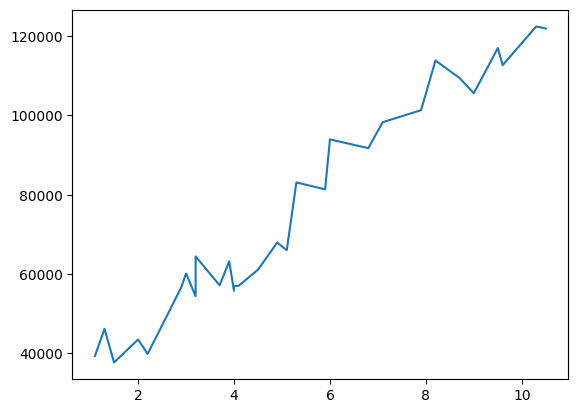

In [11]:
plt.plot(x,y)

## **Train test split**

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(24, 1) (6, 1) (24, 1) (6, 1)


### **Model Training**

In [20]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [21]:
y_pred=lr.predict(x_test)

In [28]:
final_data=pd.DataFrame(x_test, columns=['Experience'])
final_data['Salary']=pd.DataFrame(y_test)
final_data['Prediction']=pd.DataFrame(y_pred)
final_data['Difference']=pd.DataFrame(y_pred-y_test)
final_data

,Experience,Salary,Prediction,Difference
0,6.8,91738,90300.067948,-1437.932052
1,1.5,37731,40652.684227,2921.684227
2,4.5,61111,68754.976900,7643.976900
3,3.7,57189,61261.032187,4072.032187
4,10.5,121872,124959.562244,3087.562244
5,7.1,98273,93110.297216,-5162.702784


In [35]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.9749605113716197


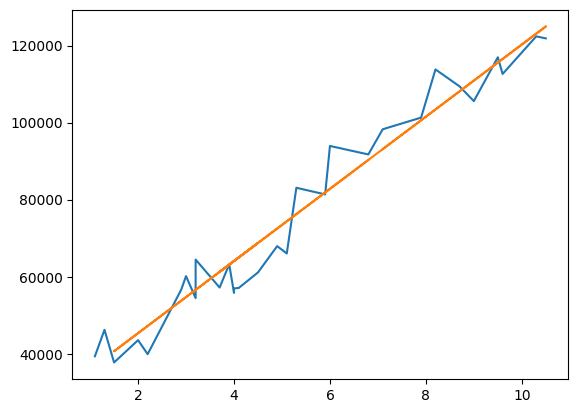

In [31]:
plt.plot(x,y)
plt.plot(x_test,y_pred)

In [37]:
print(lr.coef_)
print(lr.intercept_)

[[9367.4308908]]
[26601.53789097]


In [56]:
y_calculate = 26601.53789097+6.8*9367.4308908
print(y_calculate, lr.predict(np.array([[6.8]])))

90300.06794841 [[90300.06794838]]


## **Analysis of data for outliers Tips dataset**

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='day', ylabel='total_bill'>

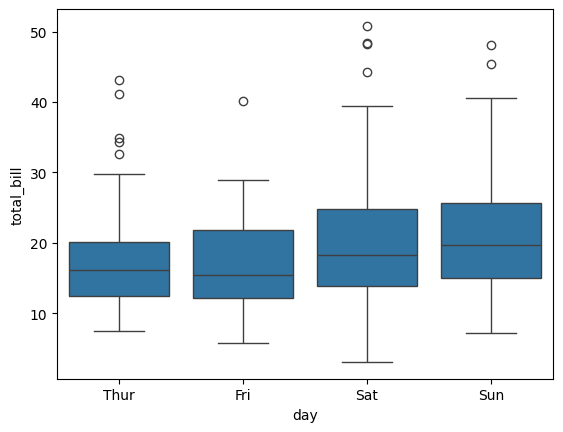

In [61]:
tips=sns.load_dataset('tips')
print(tips)
sns.boxplot(tips, x='day', y='total_bill')

In [63]:
print(tips.describe())

       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


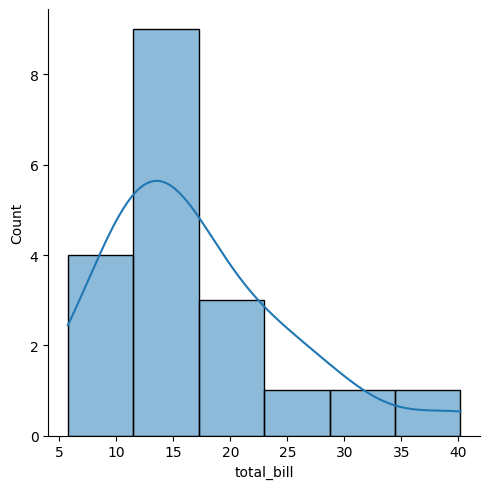

In [66]:
sns.displot(tips[tips['day']=='Fri']['total_bill'], kde=True)

In [70]:
tips['total_bill']=np.log10(tips['total_bill'])

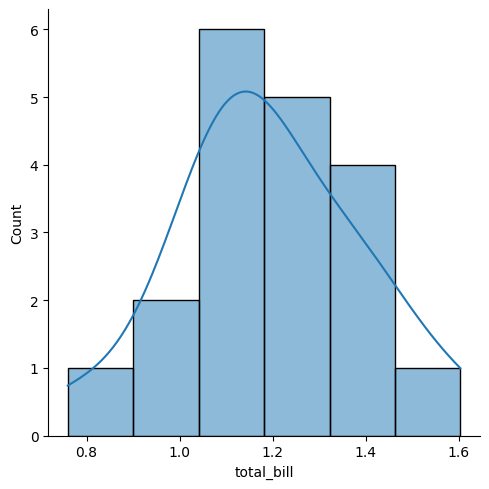

In [71]:
sns.displot(tips[tips['day']=='Fri']['total_bill'], kde=True)

,total_bill,tip,size,try
count,244.000000,244.000000,244.000000,19.000000
mean,1.255246,2.998279,2.569672,1.190316
std,0.190601,1.383638,0.951100,0.200297
min,0.487138,1.000000,1.000000,0.759668
25%,1.125398,2.000000,2.000000,1.082600
50%,1.250298,2.900000,2.000000,1.186956
75%,1.382510,3.562500,3.000000,1.337208
max,1.705949,10.000000,6.000000,1.603902


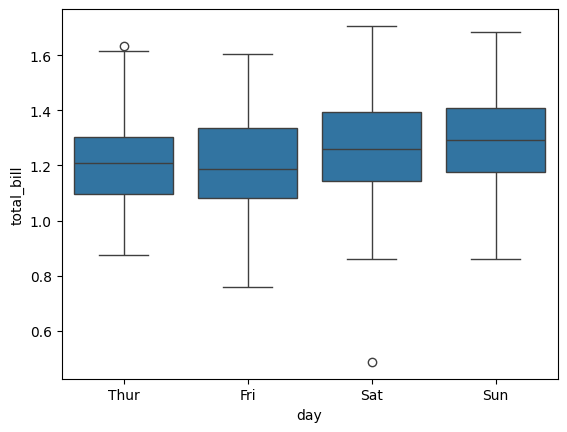

In [74]:
sns.boxplot(tips, x='day', y='total_bill')
tips.describe()